In [4]:
from sklearn.datasets import make_classification
import numpy as np
X,y = make_classification(n_samples=100,n_features=2,n_informative=1,n_redundant=0,n_classes=2,n_clusters_per_class=1,
                          random_state=41,hypercube=False,class_sep=30)
import matplotlib.pyplot as plt


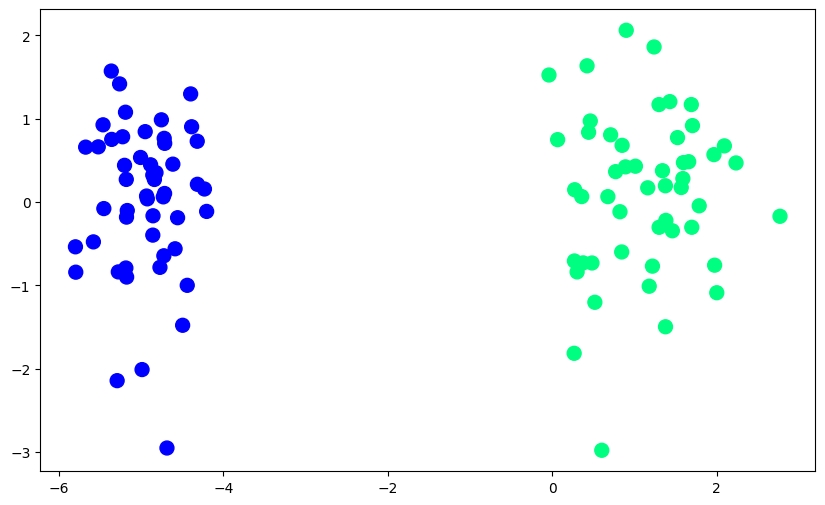

In [5]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

Perceptron Trick

In [70]:
def step(z):
  return 1 if z > 0 else 0

In [71]:
def Perceptron(X,y):
  X = np.insert(X,0,1,axis=1)
  weights = np.ones(X.shape[1])
  lr = 0.1
  for i in range(500):
    j = np.random.randint(0,100)
    y_hat = step(np.dot(X[j],weights))
    weights = weights + lr * (y[j] - y_hat) * X[j]
  return weights[0] , weights[1:]

In [72]:
intercept_,coef_ =  Perceptron(X,y)

In [73]:
intercept_

np.float64(1.2000000000000002)

In [74]:
coef_

array([1.1204053 , 0.40381514])

In [75]:
# m = (-A/B) , b = -(C / B)
m = -(coef_[0] / coef_[1])
b = -(intercept_ / coef_[1])

In [76]:
x_input = np.linspace(-3,3,100)
y_input = m * x_input + b

(-3.0, 2.0)

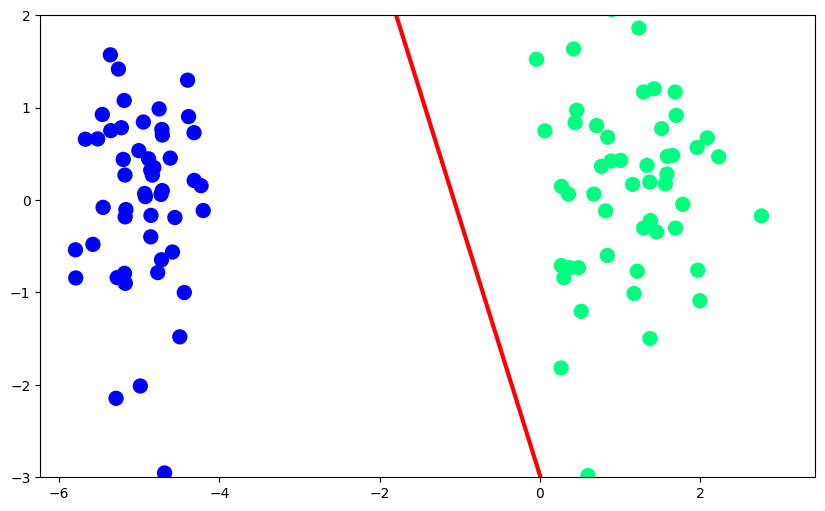

In [77]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [78]:
def Perceptron(X,y):
  m = []
  b = []
  X = np.insert(X,0,1,axis=1)
  weights = np.ones(X.shape[1])
  lr = 0.1
  for i in range(200):
    j = np.random.randint(0,100)
    y_hat = step(np.dot(X[j],weights))
    weights = weights + lr * (y[j] - y_hat) * X[j]
    m.append(-(weights[1] / weights[2]))
    b.append(-(weights[0] / weights[2]))
  return m , b

In [41]:
m , b = Perceptron(X,y)

In [42]:
%matplotlib inline  # Use inline for better animation display
from IPython.display import HTML
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

UsageError: unrecognized arguments: # Use inline for better animation display


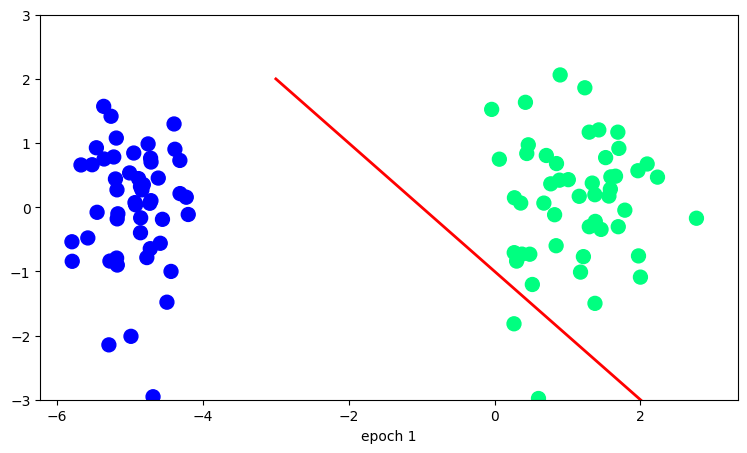

In [43]:
# Import necessary modules within the current cell
import matplotlib.animation as animation
from IPython.display import HTML
import matplotlib.pyplot as plt
import numpy as np


fig, ax = plt.subplots(figsize=(9, 5))
x_i = np.arange(-3, 3, 0.1)
y_i = x_i * m[0] + b[0]
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
line, = ax.plot(x_i, x_i * m[0] + b[0], 'r-', linewidth=2)
plt.ylim(-3, 3)


def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i * m[i] + b[i])
    ax.set_xlabel(label)
    return line, ax


anim = animation.FuncAnimation(fig, update, repeat=True, frames=200, interval=100)
HTML(anim.to_html5_video())

In [44]:
from IPython.display import HTML

In [45]:
!apt-get install ffmpeg

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.


In [79]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X,y)

LogisticRegression()

In [80]:
m = -(lor.coef_[0][0] / lor.coef_[0][1])
b = -(lor.intercept_[0] / lor.coef_[0][1])

In [81]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

In [82]:
%matplotlib inline

(-3.0, 2.0)

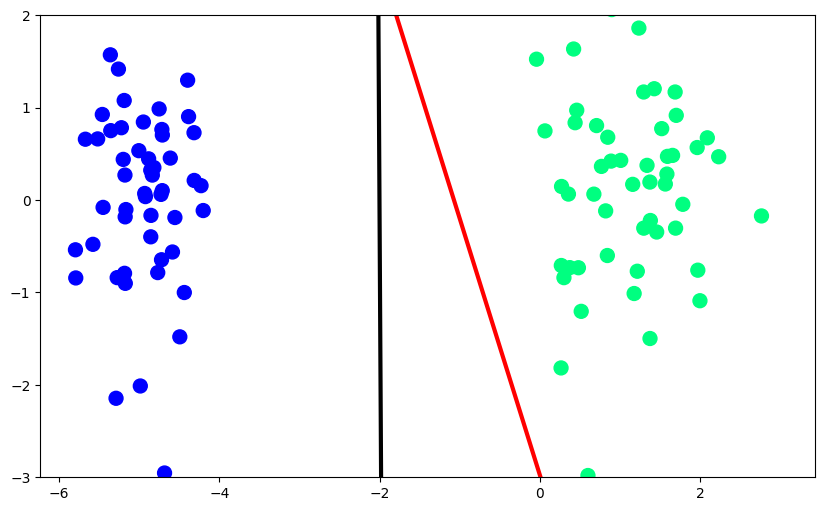

In [83]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)


Now Using Sigmoid Activation Function

In [51]:
def sigmoid(z):
  return 1 / (1+ np.exp(-z))

In [63]:
def Perceptron(X,y):
  X = np.insert(X,0,1,axis=1)
  weights = np.ones(X.shape[1])
  lr = 0.1
  for i in range(1000):
    j = np.random.randint(0,100)
    y_hat = sigmoid(np.dot(X[j] , weights))
    weights = weights +  lr * (y[j] - y_hat) * X[j]
  return weights[0] , weights[1:]

In [64]:
intercept_ , coef_ = Perceptron(X,y)

In [65]:
m = - (coef_[0] / coef_[1])
b = -(intercept_ / coef_[1])

In [66]:
m

np.float64(-7.8454720062944014)

In [67]:
b

np.float64(-8.910953644523802)

In [68]:
x_input2 = np.linspace(-3,3,100)
y_input2 = m * x_input + b

(-3.0, 2.0)

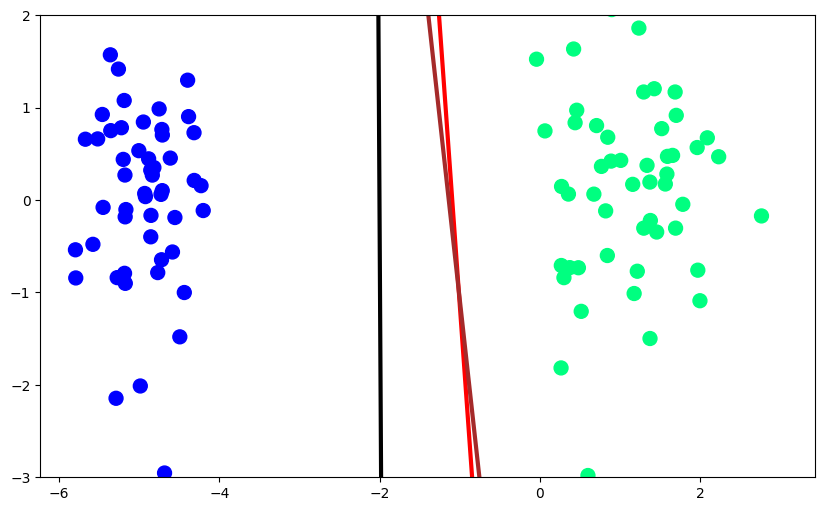

In [69]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.plot(x_input2,y_input2,color='brown',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)